## **Decoding Delhi’s Air Quality** : Exploring Air Pollution (AQI) Patterns and Weather Influence in 2025



# **Introduction**

---

Air pollution is one of the major environmental challenges affecting human health and urban development. Rapid urbanization, industrial growth, vehicular emissions, and changing weather conditions contribute significantly to the deterioration of air quality.

Air pollution in Delhi has become a critical environmental and public health issue. Despite continuous monitoring, pollution levels fluctuate significantly across different locations and time periods, making it difficult to implement timely and effective pollution control measures.



# **Problem Statement**
---

Modern urban management requires a deeper understanding of how environmental and meteorological factors influence air quality. Monitoring and analyzing environmental data is essential for identifying pollution patterns and understanding the factors affecting AQI levels.

This project focuses on analyzing hourly AQI and weather data across multiple locations in Delhi to uncover patterns, trends, and relationships that influence pollution levels.


# **Objective of the Analysis**
---

* To perform Exploratory Data Analysis (EDA) on Delhi’s AQI and weather dataset.
* To identify trends and patterns in air pollution levels across different locations.
* To analyze the relationship between weather conditions and AQI.
* To study the impact of pollutants such as PM2.5, PM10, NO₂, and CO on air quality.
* To identify high-risk pollution periods and pollution-prone locations.
* To generate meaningful insights using statistical analysis and data visualization techniques.


# **Tools & Technologies Used**
---

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter Notebook

In [ ]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Understanding the data set

In [ ]:
# reading the csv file
df=pd.read_csv("/content/DelhiWeatherAqi_2025.csv")

In [ ]:
df.head()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [ ]:
# shape of the data
df.shape

(52560, 16)

**Basic Description of the data set**

    1.   52,560 no of records
    2.   16 no of features/columns

**About Features**

In [ ]:
df.columns

Index(['date_ist', 'time_ist', 'location', 'lat', 'lon', 'temp_c', 'humidity',
       'pressure_mb', 'windspeed_kph', 'condition_text', 'description',
       'aqi_index', 'pm2_5', 'pm10', 'co', 'no2'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_ist        52560 non-null  object 
 1   time_ist        52560 non-null  object 
 2   location        52560 non-null  object 
 3   lat             52560 non-null  float64
 4   lon             52560 non-null  float64
 5   temp_c          52560 non-null  float64
 6   humidity        52560 non-null  int64  
 7   pressure_mb     52560 non-null  float64
 8   windspeed_kph   52560 non-null  float64
 9   condition_text  52560 non-null  object 
 10  description     52560 non-null  object 
 11  aqi_index       52560 non-null  int64  
 12  pm2_5           52560 non-null  float64
 13  pm10            52560 non-null  float64
 14  co              52560 non-null  int64  
 15  no2             52560 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 6.4+ MB


**Category of the Features and Their description**


----------------------------------------------------------------------


1.   **Real Numerical**

        1. **temp_c** : Ambient Temperature	Celsius (°C)
        hot -
        cold -
        moderate -
        
        2. **humidity** : Relative Humidity	Percentage (%)
        3. **pressure_mb** : Atmospheric Pressure	Millibars (mb)
        4. **windspeed_kph** : Wind Speed	Kilometers per hour (kph)
        5. **aqi_index** : Air Quality Index Value (Numerical Index)
        6. **pm2_5** : Particulate Matter < 2.5 micrometers ( µg/m³)
        7. **pm10** : Particulate Matter < 10 micrometers ( µg/m³ )
        8. **co** : Carbon Monoxide concentration ( µg/m³ )
        9. **no2** : Nitrogen Dioxide concentration ( µg/m³ )

2.   **categorical / discrete numerical**

        1. **location** : Specific location within Delhi
        2. **date_ist** : Date of the observation (Indian Standard Time)(DD/MM/YYYY)
        3. **condition_text** : Weather Condition Description	Text.
        4. **time_ist** : Time of the observation (Indian Standard Time)(H:MM (24-hour format))
        5. **lat** : Latitude of the location
        6. **lon** : Longitude of the location

3.   **Other**

        1. **description** : WMO Weather Code Description



       

In [ ]:
df.sample(10)

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
14576,12/04/2025,8:00,Connaught Place,28.6304,77.2177,24.8,61,983.7,2.2,Clear sky,WMO Code 0,443,72.6,268.2,798,25.5
18399,08/05/2025,15:00,Rohini,28.7041,77.1025,31.8,47,979.2,8.7,Overcast,WMO Code 3,155,55.9,356.7,407,6.6
8795,03/03/2025,11:00,Anand Vihar,28.6469,77.3160,23.9,39,989.9,2.5,Clear sky,WMO Code 0,152,33.6,44.0,758,19.4
24527,20/06/2025,23:00,Connaught Place,28.6304,77.2177,27.7,90,976.1,6.8,Overcast,WMO Code 3,113,77.5,238.0,706,48.6
18620,10/05/2025,20:00,Connaught Place,28.6304,77.2177,29.5,65,981.1,2.3,Partly cloudy,WMO Code 2,182,43.2,76.8,734,20.3
37099,15/09/2025,19:00,Okhla Phase III,28.5273,77.2618,33.4,48,977.3,5.6,Overcast,WMO Code 3,124,39.1,64.3,454,65.2
45998,16/11/2025,14:00,Dwarka,28.5882,77.0494,26.2,26,994.3,11.6,Clear sky,WMO Code 0,165,38.6,40.3,456,10.8
1724,12/01/2025,20:00,IGI Airport,28.5562,77.1000,12.4,94,992.4,7.2,Clear sky,WMO Code 0,174,132.7,134.6,1382,70.0
27648,12/07/2025,0:00,Anand Vihar,28.6469,77.3160,27.4,91,978.9,2.7,Overcast,WMO Code 3,157,117.6,122.9,1063,100.4
33279,20/08/2025,15:00,Anand Vihar,28.6469,77.3160,32.3,64,975.9,10.7,Drizzle: Light,WMO Code 51,120,22.8,35.5,369,7.4


## **Subject Background**

---

1.   **Humidity** : in the percentage.(0-100)
2.   **pressure_mb**	Pressure is low below 1000 mb, normal around 1013 mb, and high above 1020 mb.
3.  **aqi** is not caluculated where it is derived from multiple pollutants, each converted into a sub-index, and then the maximum of those sub-indices becomes the AQI.

range(0-500)
*   0 – 50 → Good 😊
*   51 – 100 → Satisfactory
*   101 – 200 → Moderate
*   201 – 300 → Poor
*   301 – 400 → Very Poor
*   401 – 500 → Severe











4.  **wind_speed** (  Based on the Beaufort scale)

*   0 - 5 km/h → Calm
*   6 - 20 km/h → Light wind
*   21 - 40 km/h → Moderate wind
*   41 - 60 km/h → Strong wind
*   > 60 km/h → Very strong / Storm

5. **pm2.5** (WHO)
Based on common AQI categories:

*  0 - 12 µg/m³ → Good
*  12 - 35 µg/m³ → Moderate
*   35 - 55 µg/m³ → Unhealthy for sensitive groups
*   55 - 150 µg/m³ → Unhealthy
*   150 - 250 µg/m³ → Very unhealthy
*   > 250 µg/m³ → Hazardous

6. **pm10**

*   0 - 50 µg/m³ → Good
*   50 - 100 µg/m³ → Moderate
*   100 - 250 µg/m³ → Unhealthy for sensitive groups
*   250 - 350 µg/m³ → Unhealthy
*   350 - 430 µg/m³ → Very unhealthy
*   > 430 µg/m³ → Hazardous

7. **co**

*   0 - 1000 → Good
*   1000 - 2000 → Satisfactory
*   2000 - 10000 → Moderate
*   10000 - 17000 → Poor
*   17000 - 34000 → Very Poor
*   > 34000 - Severe

8. **no2**

*   0 - 40 → Good
*   41 - 80 → Satisfactory
*   81 - 180 → Moderate
*   181 - 280 → Poor
*   281 - 400 → Very Poor
*   > 400 → Severe











## **How These Pollutants Are Released**

---

* **PM2.5 (Fine Particles):**
  Released from vehicle exhaust, industrial smoke, burning of fuel, waste burning, and construction activities.

* **PM10 (Dust Particles):**
  Mainly released from road dust, construction work, mining activities, and dust storms.

* **NO₂ (Nitrogen Dioxide):**
  Produced during fuel combustion from vehicles, power plants, factories, and diesel generators.

* **CO (Carbon Monoxide):**
  Released when fuels like petrol, diesel, coal, wood, or gas burn incompletely, mainly from vehicles and industries.

* **AQI (Air Quality Index):**
  AQI itself is not a pollutant; it is an index that measures overall air pollution based on pollutants like PM2.5, PM10, NO₂, CO, etc.


# **Data Cleaning**

**Observations about the incorrect features**

---

1. **"date_ist"** is of object type need  **"Date time format"**
2. **"time_ist"** is of object type need  **"date time format"**
3. **description** is duplicate of the **condition_text**







**Handling the incorrect features**


---

1. Adding new Feature Datetime By combining the date_ist and time_ist
2. Dropping the date_ist and time_ist
3. Dropping the description feature
4. renaming the column names
5. rearranging the features


In [ ]:
# Adding new Feature Datetime By combining the date_ist and time_ist
df['datetime']=pd.to_datetime(df['date_ist']+" "+df['time_ist'],format='%d/%m/%Y %H:%M')

In [ ]:
# dropping the unwanted features
df.drop(columns=['date_ist','time_ist','description'],inplace=True)

In [ ]:
# renaming the column names
df.rename(columns={"temp_c":"temp","pressure_mb":"pressure","windspeed_kph":"windspeed","condition_text":"weather"},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   location   52560 non-null  object        
 1   lat        52560 non-null  float64       
 2   lon        52560 non-null  float64       
 3   temp       52560 non-null  float64       
 4   humidity   52560 non-null  int64         
 5   pressure   52560 non-null  float64       
 6   windspeed  52560 non-null  float64       
 7   weather    52560 non-null  object        
 8   aqi_index  52560 non-null  int64         
 9   pm2_5      52560 non-null  float64       
 10  pm10       52560 non-null  float64       
 11  co         52560 non-null  int64         
 12  no2        52560 non-null  float64       
 13  datetime   52560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(8), int64(3), object(2)
memory usage: 5.6+ MB


In [ ]:
df.columns.tolist()

['location',
 'lat',
 'lon',
 'temp',
 'humidity',
 'pressure',
 'windspeed',
 'weather',
 'aqi_index',
 'pm2_5',
 'pm10',
 'co',
 'no2',
 'datetime']

In [ ]:
# rearranging the features
df=df[[ 'datetime',
  'location',
 'lat',
 'lon',
 'temp',
 'humidity',
 'pressure',
 'windspeed',
 'weather',
 'aqi_index',
 'pm2_5',
 'pm10',
 'co',
 'no2'
]]

In [ ]:
df.head()

,datetime,location,lat,lon,temp,humidity,pressure,windspeed,weather,aqi_index,pm2_5,pm10,co,no2
0,2025-01-01 00:00:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,197,185.8,188.6,1907,56.7
1,2025-01-01 01:00:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,198,174.6,177.4,1669,44.8
2,2025-01-01 02:00:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,199,164.4,166.7,1493,34.6
3,2025-01-01 03:00:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,200,156.5,158.8,1401,26.7
4,2025-01-01 04:00:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,200,149.5,151.8,1372,20.6


**Need Verification**


---
1. location format checking
2. weather format checking
3. Any date is missing
4. Any place name for given lat and long
5. Humidity with in the range (0-100)
6. AQi Index with in the range (0-500)
7. pm2.5/p.10/co/no2 should not contain any negative values
8. Any Null values



In [ ]:
# checking  formatting of feature (location  and conditio_test)

print(df['location'].value_counts())
df['weather'].value_counts()


location
Anand Vihar        8760
Connaught Place    8760
Dwarka             8760
Okhla Phase III    8760
Rohini             8760
IGI Airport        8760
Name: count, dtype: int64


,count
weather,
Clear sky,30086
Overcast,10285
Mainly clear,4444
Drizzle: Light,3090
Partly cloudy,2557
Drizzle: Moderate,643
Rain: Moderate,421
Rain: Slight,416
Fog,334


**Conclusion**:
The "locations" and "weather" feature  is  correctly formatted which correct spelling and the case so need of data handling

In [ ]:
# Any wrong  place name for given lat
df.groupby('location')['lat'].nunique()


,lat
location,
Anand Vihar,1
Connaught Place,1
Dwarka,1
IGI Airport,1
Okhla Phase III,1
Rohini,1


In [ ]:
# Any wrong  place name for given lon
df.groupby('location')['lon'].nunique()

,lon
location,
Anand Vihar,1
Connaught Place,1
Dwarka,1
IGI Airport,1
Okhla Phase III,1
Rohini,1


In [ ]:
# Humidity should be  in the range (0-100)

print(f"Humidity range : {df['humidity'].min()}-{df['humidity'].max()}")


Humidity range : 5-100


In [ ]:
# AQi Index with in the range (0-500)
print(f"AQI_index  range : {df['aqi_index'].min()}-{df['aqi_index'].max()}")


(df['aqi_index']>500).value_counts()



AQI_index  range : 56-2742


,count
aqi_index,
False,45657
True,6903


**observation** : Many aqi values are beyond the range limit

**Analyzing the reason for aqi index out of range**

In [ ]:
df[df['aqi_index']>500].groupby('location').count()

,datetime,lat,lon,temp,humidity,pressure,windspeed,weather,aqi_index,pm2_5,pm10,co,no2
location,,,,,,,,,,,,,
Anand Vihar,290,290,290,290,290,290,290,290,290,290,290,290,290
Connaught Place,290,290,290,290,290,290,290,290,290,290,290,290,290
Dwarka,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011
IGI Airport,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011
Okhla Phase III,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011
Rohini,290,290,290,290,290,290,290,290,290,290,290,290,290


In [ ]:
x=df[df['aqi_index']>500].groupby('location')

In [ ]:
x[['datetime','aqi_index']].get_group('Dwarka').groupby(df['datetime'].dt.month).count()
x[['datetime','aqi_index']].get_group('Dwarka').groupby(df['datetime'].dt.date).count()

,datetime,aqi_index
datetime,,
2025-03-04,9,9
2025-03-05,24,24
2025-03-06,24,24
2025-03-07,15,15
2025-03-08,16,16
...,...,...
2025-08-09,15,15
2025-08-11,10,10
2025-08-12,2,2


In [ ]:
x.get_group('IGI Airport').groupby(df['datetime'].dt.month).head(10)
# x[['datetime','aqi_index']].get_group('IGI Airport').groupby(df['datetime']).count().head(10)

,datetime,location,lat,lon,temp,humidity,pressure,windspeed,weather,aqi_index,pm2_5,pm10,co,no2
9063,2025-03-04 15:00:00,IGI Airport,28.5562,77.1,24.1,42,986.0,14.9,Mainly clear,514,132.7,1229.3,350,6.5
9064,2025-03-04 16:00:00,IGI Airport,28.5562,77.1,23.5,41,986.1,15.8,Clear sky,558,161.1,1527.4,349,9.8
9065,2025-03-04 17:00:00,IGI Airport,28.5562,77.1,22.0,48,986.4,18.6,Clear sky,614,214.2,2004.2,351,12.6
9066,2025-03-04 18:00:00,IGI Airport,28.5562,77.1,20.7,52,987.3,15.4,Clear sky,689,235.2,2093.6,360,15.9
9067,2025-03-04 19:00:00,IGI Airport,28.5562,77.1,19.8,52,987.7,14.0,Clear sky,768,245.9,2130.9,371,20.3
9068,2025-03-04 20:00:00,IGI Airport,28.5562,77.1,18.8,52,988.2,14.8,Clear sky,831,249.6,2130.9,381,23.1
9069,2025-03-04 21:00:00,IGI Airport,28.5562,77.1,17.6,53,988.6,14.0,Clear sky,880,252.4,2108.5,390,22.8
9070,2025-03-04 22:00:00,IGI Airport,28.5562,77.1,16.8,55,988.9,13.9,Clear sky,926,258.9,2130.9,396,20.8
9071,2025-03-04 23:00:00,IGI Airport,28.5562,77.1,16.1,57,988.7,13.9,Clear sky,978,264.5,2153.2,394,18.4
9192,2025-03-05 00:00:00,IGI Airport,28.5562,77.1,15.4,59,988.3,14.3,Clear sky,1041,268.2,2190.5,374,15.7


In [ ]:
x[['datetime','aqi_index']].get_group('Okhla Phase III').groupby(df['datetime'].dt.month).count()

# x[['datetime','aqi_index']].get_group('Okhla Phase III').groupby(df['datetime'].dt.date).count()
x.get_group('Okhla Phase III').groupby(df['datetime'].dt.month).head(10)

,datetime,location,lat,lon,temp,humidity,pressure,windspeed,weather,aqi_index,pm2_5,pm10,co,no2
9015,2025-03-04 15:00:00,Okhla Phase III,28.5273,77.2618,25.3,34,986.3,15.3,Mainly clear,514,132.7,1229.3,350,6.5
9016,2025-03-04 16:00:00,Okhla Phase III,28.5273,77.2618,24.5,36,986.4,15.7,Mainly clear,558,161.1,1527.4,358,9.8
9017,2025-03-04 17:00:00,Okhla Phase III,28.5273,77.2618,23.5,38,986.6,16.3,Mainly clear,614,214.2,2004.2,373,12.6
9018,2025-03-04 18:00:00,Okhla Phase III,28.5273,77.2618,21.5,48,987.7,17.8,Clear sky,689,235.2,2093.6,399,15.9
9019,2025-03-04 19:00:00,Okhla Phase III,28.5273,77.2618,20.6,50,988.1,14.5,Clear sky,768,245.9,2130.9,431,20.3
9020,2025-03-04 20:00:00,Okhla Phase III,28.5273,77.2618,19.9,47,988.5,15.8,Clear sky,831,249.6,2130.9,452,23.1
9021,2025-03-04 21:00:00,Okhla Phase III,28.5273,77.2618,18.8,48,988.9,15.8,Clear sky,880,252.4,2108.5,454,22.8
9022,2025-03-04 22:00:00,Okhla Phase III,28.5273,77.2618,18.0,49,989.3,15.1,Clear sky,926,258.9,2130.9,444,20.8
9023,2025-03-04 23:00:00,Okhla Phase III,28.5273,77.2618,17.1,52,989.1,14.6,Clear sky,978,264.5,2153.2,427,18.4
9144,2025-03-05 00:00:00,Okhla Phase III,28.5273,77.2618,16.4,54,988.6,14.5,Clear sky,1041,268.2,2190.5,399,15.7


**Reason** : According to CPCB (Central Pollution Control Board) and standard AQI guidelines, the AQI scale is officially bounded between 0 and 500. During calculation, some pollutant concentrations exceeded the highest defined breakpoint ranges, which caused the interpolation formula to mathematically generate values above 500. Since AQI values beyond 500 are not officially categorized separately and are all considered ‘Severe’, the AQI values were clipped to 500 to maintain compliance with the standard AQI scale

**Conclusion**: The values of aqi are above the 500 becoz of high pollutants need to clip to 500

In [ ]:
# pm2.5/p.10/co/no2 should not contain any negative values
print(f"pm 2_5 : {df['pm2_5'].min()}-{df['pm2_5'].max()}")
print(f"pm 10 : {df['pm10'].min()}-{df['pm10'].max()}")
print(f"c0 : {df['co'].min()}-{df['co'].max()}")
print(f"no2 : {df['no2'].min()}-{df['no2'].max()}")

pm 2_5 : 6.0-443.3
pm 10 : 6.1-3263.4
c0 : 146-7432
no2 : 1.7-220.1


**Conclusion** : There are no negative values so no need to handle the  values of the above pollutants .

**Observations about incorrect data**


---

1.Handling out of range aqi values by clipping it to maximum 500


In [ ]:
# Handling aqi values
# df.loc[df['aqi_index'] > 500] = 500
df.loc[df['aqi_index'] > 500, 'aqi_index'] = 500


## **Handling incorrect data**

In [ ]:
(df['aqi_index']>500).value_counts()

,count
aqi_index,
False,52560


**Identifying  and handling the null values**

In [ ]:
# Any Null values
# Percentage of the missing values
df.isnull().mean()*100

,0
datetime,0.0
location,0.0
lat,0.0
lon,0.0
temp,0.0
humidity,0.0
pressure,0.0
windspeed,0.0
weather,0.0
aqi_index,0.0


**Observation** : There are no null values

**Identifying any missing dates**

In [ ]:
x=df['datetime'].dt.month_name().value_counts()
x

,count
datetime,
January,4464
March,4464
July,4464
May,4464
December,4464
October,4464
August,4464
April,4320
September,4320


In [ ]:
df['location'].value_counts()

,count
location,
Anand Vihar,8760
Connaught Place,8760
Dwarka,8760
Okhla Phase III,8760
Rohini,8760
IGI Airport,8760


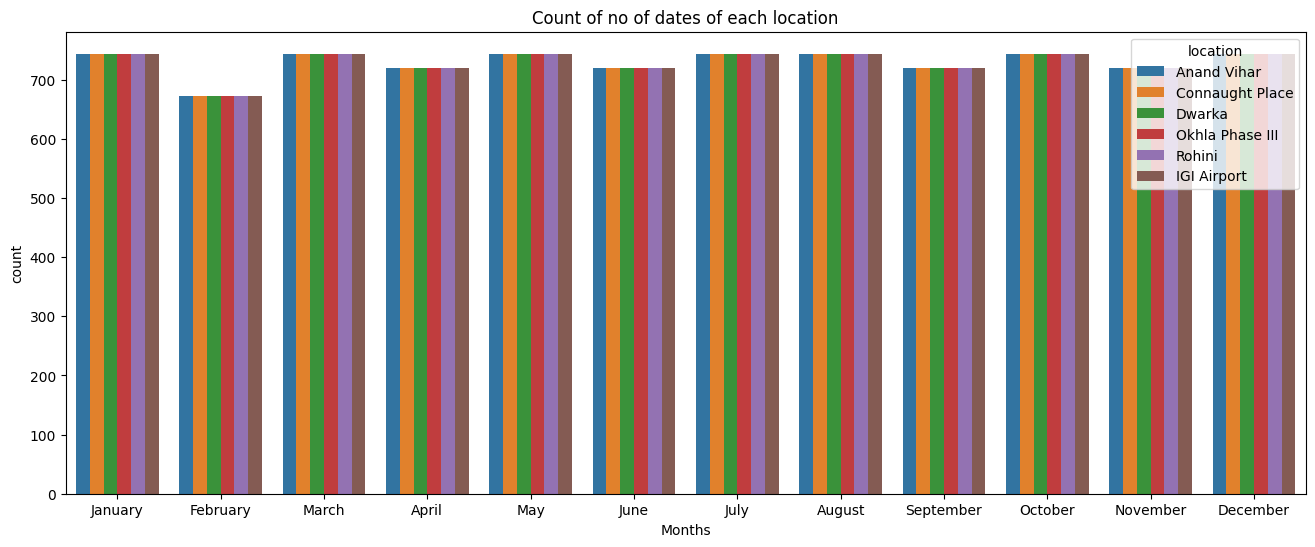

In [ ]:
# Analysing any relation between the missing data and the locations
plt.figure(figsize=(16,6))
sns.countplot(x=df['datetime'].dt.month_name(),hue=df['location'])
plt.title("Count of no of dates of each location")
plt.xlabel('Months')
plt.show()

**Observation** : The information in some dates are missing for every location equally.

**Identifying and Handling Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

**conclusion** Their are no duplicated for the given data set .

**Identifying the outliers**

2 0
2 1
2 2


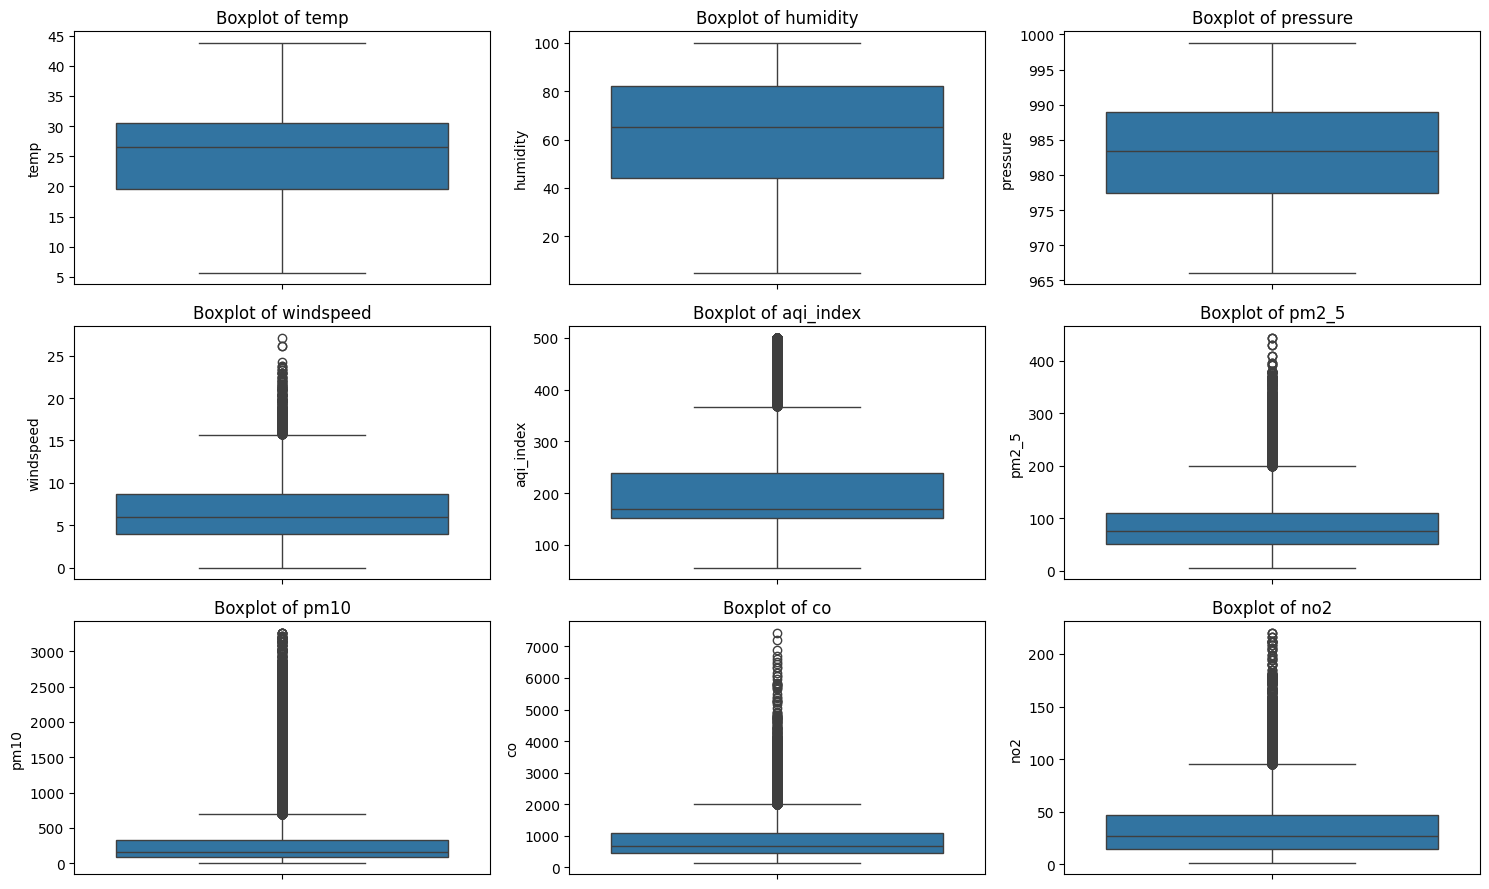

In [ ]:
parameters=['temp','humidity','pressure','windspeed','aqi_index','pm2_5','pm10','co','no2']
fig,ax=plt.subplots(3,3,figsize=(15,9))
start=0
count=0
for col in parameters:
  sns.boxplot(df[col], ax=ax[start][count])
  ax[start][count].set_title(f'Boxplot of {col}')
  if count==2:
    print(count,start)
    start+=1
    count=0
  else:
    count+=1
    plt.show
plt.tight_layout()


**Observation** : There are extreme large values in the data of every numerical column except in temparature and humidity column and they are very important to analyze where extreme values and when it is raising so i am not handling it .

In [ ]:
df.isnull().sum()

,0
datetime,0
location,0
lat,0
lon,0
temp,0
humidity,0
pressure,0
windspeed,0
weather,0
aqi_index,0


# Exploratory data Analysis

**Describing the Locations**

In [ ]:
#Locations and latitudes
df.groupby('location')['lat'].unique()

,lat
location,
Anand Vihar,[28.6469]
Connaught Place,[28.6304]
Dwarka,[28.5882]
IGI Airport,[28.5562]
Okhla Phase III,[28.5273]
Rohini,[28.7041]


In [ ]:
df.groupby('location')['lon'].unique()

,lon
location,
Anand Vihar,[77.316]
Connaught Place,[77.2177]
Dwarka,[77.0494]
IGI Airport,[77.1]
Okhla Phase III,[77.2618]
Rohini,[77.1025]


In [ ]:
df['lat'].unique()

array([28.6469, 28.6304, 28.5882, 28.5273, 28.7041, 28.5562])

In [ ]:
df['lon'].unique()

array([77.316 , 77.2177, 77.0494, 77.2618, 77.1025, 77.1   ])

In [ ]:
df['location'].unique()

array(['Anand Vihar', 'Connaught Place', 'Dwarka', 'Okhla Phase III',
       'Rohini', 'IGI Airport'], dtype=object)

**plotting  the Locations**

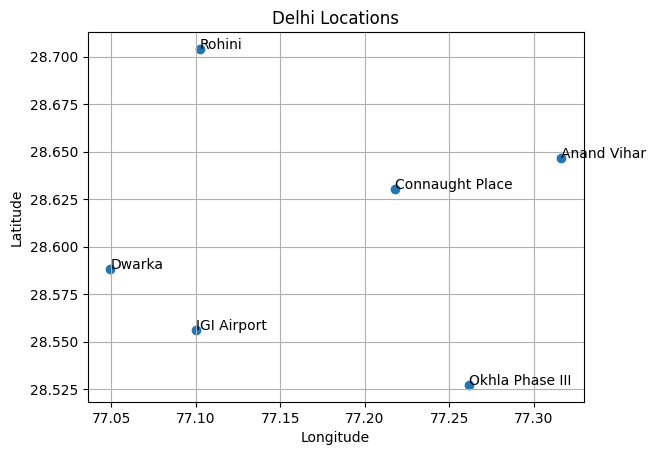

In [ ]:
# Latitude values
latitudes = df['lat'].unique()

# Longitude values
longitudes = df['lon'].unique()

places=df['location'].unique()

# Scatter plot
plt.scatter(longitudes, latitudes)

# Add point labels
for i in range(len(latitudes)):
    plt.text(longitudes[i], latitudes[i],places[i])

plt.title("Delhi Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")



plt.grid(True)

plt.show()

In [ ]:
# estimator=None, ,dashes=False,style=df['location'], markers=True,

# months = ['Jan','Feb','Mar','Apr']

# df['month'] = pd.Categorical(
#     df['month'],
#     categories=months,
#     ordered=True
# )

## **Key Question Analysis**

**Q . What are the overall air pollution (AQI) trends across 2025?**

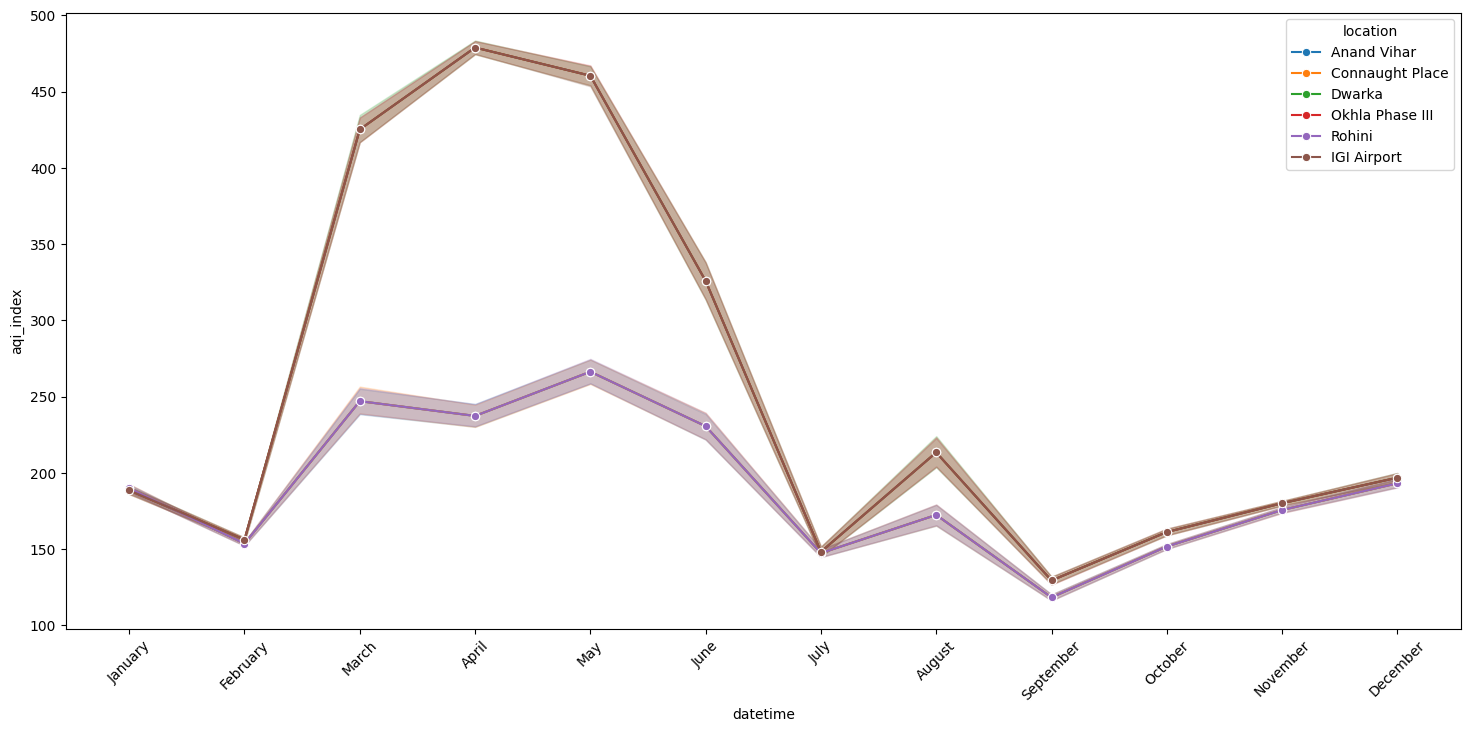

In [ ]:

plt.figure(figsize=(18,8))
ax=sns.lineplot(y=df['aqi_index'],x=df['datetime'].dt.month_name(),hue=df['location'], marker='o')
plt.xticks(rotation=45)
plt.show()

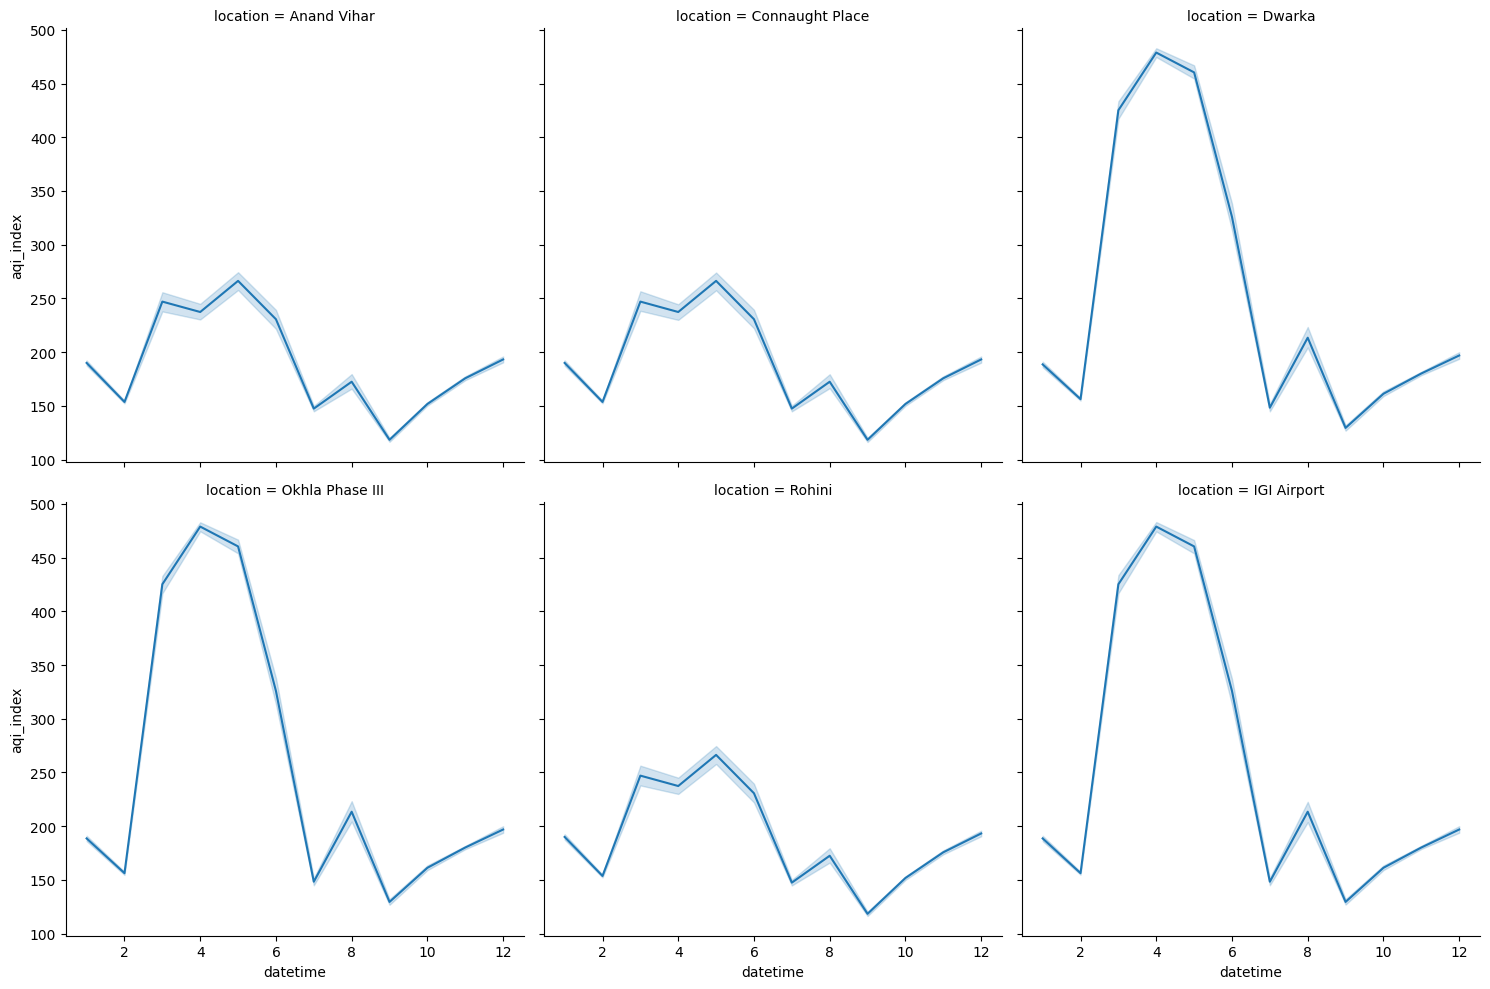

In [ ]:
sns.relplot(
    data=df,
    x=df['datetime'].dt.month,
    y='aqi_index',
    kind='line',
    col='location',
    col_wrap=3
)
plt.tight_layout()

Summer: march to June (hot and dry, peaking over)

Monsoon: July to mid-September (hot and highly humid with heavy rainfall)

Winter: october to february  (cold and dry, with temperatures often dropping below )

### Key Insights from AQI Trend Graph

* **March to May** recorded the **highest AQI levels** across all locations.
* **Dwarka, Okhla Phase III, and IGI Airport** showed **extreme AQI spikes**, reaching around **450–480 AQI**.
* **May** appears to be the **peak pollution month** overall.
* **July and September** had the **lowest AQI values**, showing the positive impact of rainfall and monsoon.
* After September, AQI starts **gradually increasing again** toward winter months.
* **Anand Vihar, Rohini, and Connaught Place** maintained comparatively lower AQI than industrial/high-traffic areas.
* All locations follow a **similar seasonal pollution pattern**, indicating weather strongly influences air quality.
* The graph shows a **sharp rise before summer and sharp fall during monsoon**.

### Short Conclusion

* **Summer months are the most polluted period in Delhi.**
* **Monsoon season significantly improves air quality.**
* Traffic-heavy and industrial zones consistently experience worse AQI levels.


**Q . Which pollutants (PM2.5, PM10, NO₂, CO) contribute most to poor air quality?**

<Axes: >

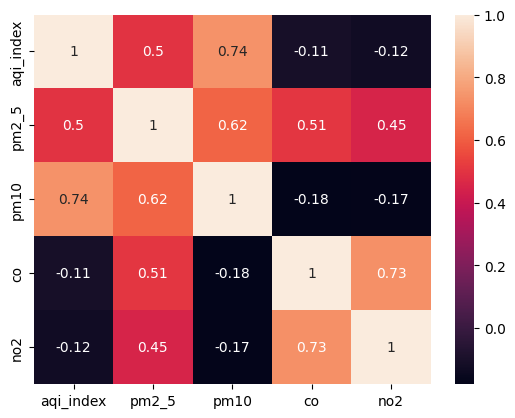

In [ ]:
sns.heatmap(df[['aqi_index','pm2_5','pm10','co','no2']].corr(),annot=True)



### Key Insights from Correlation Heatmap

* **AQI and PM10** have a **strong positive correlation (0.74)**
  → PM10 is a major contributor to poor air quality.

* **AQI and PM2.5** show a **moderate positive correlation (0.50)**
  → Fine particles also significantly affect AQI.

* **PM2.5 and PM10** are strongly related **(0.62)**
  → Both particulate pollutants tend to increase together.

* **CO and NO2** have a **strong positive correlation (0.73)**
  → Likely caused by common sources such as vehicle emissions and fuel combustion.

* **AQI has weak negative correlation with CO (-0.11) and NO2 (-0.12)**
  → Their direct influence on AQI is smaller compared to particulate matter.

* **PM10 has slight negative relation with CO and NO2**
  → Indicates particulate pollution behaves differently from gaseous pollutants in some periods.

### Short Conclusion

* **Particulate matter (PM10 and PM2.5) is the main driver of AQI deterioration.**
* **Vehicle and combustion emissions mainly influence CO and NO2 together.**
* Controlling **dust and particulate emissions** can significantly improve Delhi’s air quality.


**Q . The relation between the pm 10 and the aqi value with locations**

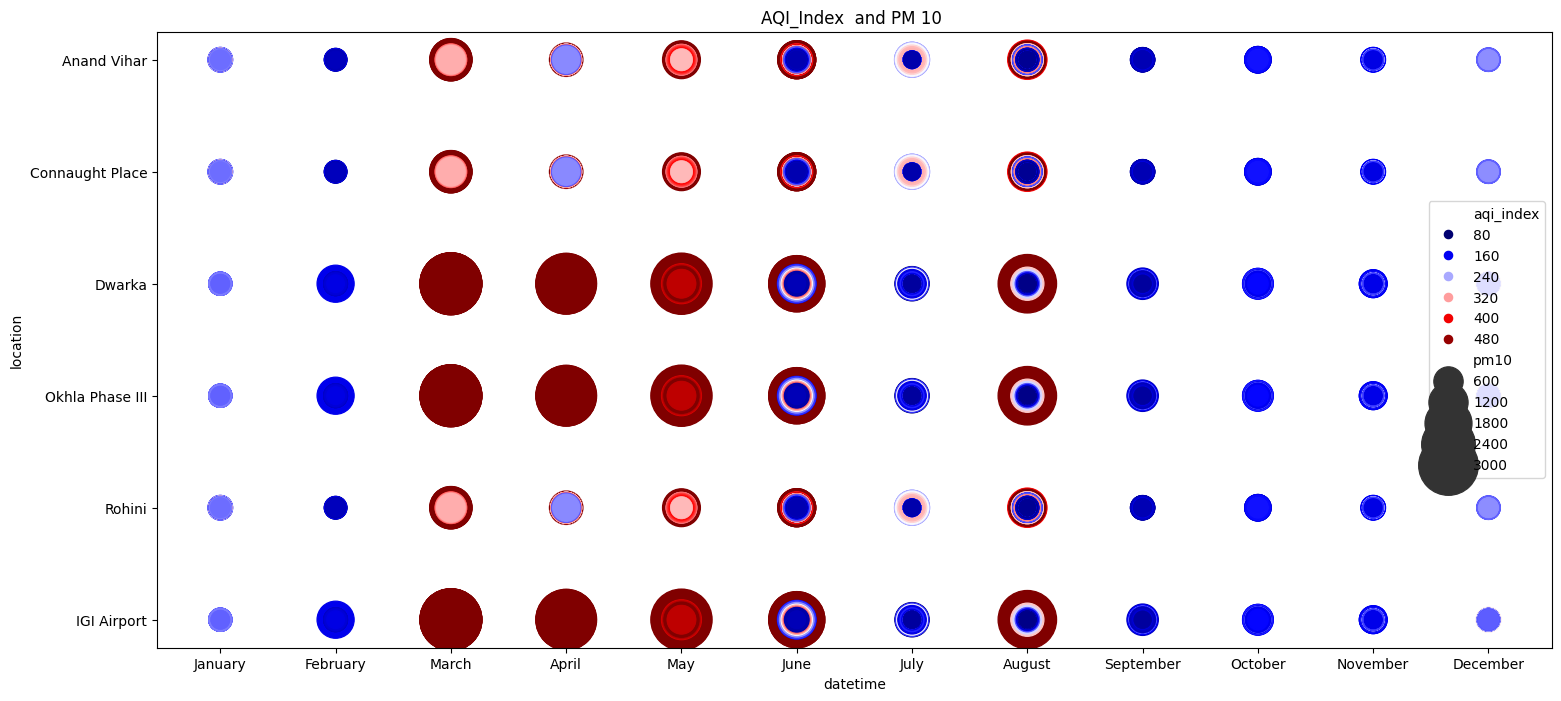

In [ ]:
plt.figure(figsize=(18,8))

scatter = sns.scatterplot(
    y=df['location'],
    x=df['datetime'].dt.month_name(),
    hue=df['aqi_index'],
    size=df['pm10'],
    palette='seismic',
    sizes=(100, 2000),
   edgecolor=None

)

plt.title("AQI_Index  and PM 10 ")

plt.show()



### Key Insights from AQI_Index and PM10 Graph

* **March, April, and May** show the **highest pollution levels** across almost all locations.
* **Dwarka, Okhla Phase III, and IGI Airport** are the **most polluted locations**, especially for **PM10**.
* **PM10 concentration is extremely high** in **March–May**, indicating heavy dust, construction activity, and dry weather impact.
* **June to August** show a **moderate reduction** in pollution due to monsoon effects and rainfall.
* **September to November** have comparatively **better AQI and lower PM10** levels.
* **December and January** still show noticeable AQI levels because of winter conditions and trapped pollutants.
* **Connaught Place and Anand Vihar** maintain moderate pollution throughout the year but peak during summer months.
* **Rohini** has relatively balanced pollution compared to industrial/high-traffic zones.
* The graph clearly indicates a **strong relationship between AQI and PM10** — whenever PM10 rises, AQI also becomes severe.

### Short Overall Conclusion

* **Summer months (March–May)** are the most critical pollution period.
* **Dwarka and Okhla Phase III** need stronger pollution control measures.
* **Rainfall season helps reduce particulate matter significantly.**
* **PM10 is one of the major contributors to AQI deterioration** in Delhi.


In [ ]:
# 0 – 50 → Good 😊
# 51 – 100 → Satisfactory
# 101 – 200 → Moderate
# 201 – 300 → Poor
# 301 – 400 → Very Poor
# 401 – 500 → Severe


def aqi_categorize(aqi):
    if aqi<50:
      return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return 'Moderate'

    elif aqi <= 300:
        return 'Poor'

    elif aqi <= 400:
        return 'Very Poor'

    else:
        return 'Severe'


In [ ]:

df['aqi_categorical']=df['aqi_index'].apply(aqi_categorize)

order=['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
# pd.Categorical(df['aqi_categorical'],order,ordered=True)

In [ ]:
df['aqi_categorical'].sample(10)

,aqi_categorical
19051,Very Poor
10457,Very Poor
19179,Very Poor
35060,Satisfactory
22317,Severe
31887,Poor
12294,Very Poor
17525,Poor
14661,Poor
40493,Moderate


**Q.How frequently does AQI reach unhealthy or hazardous levels?**

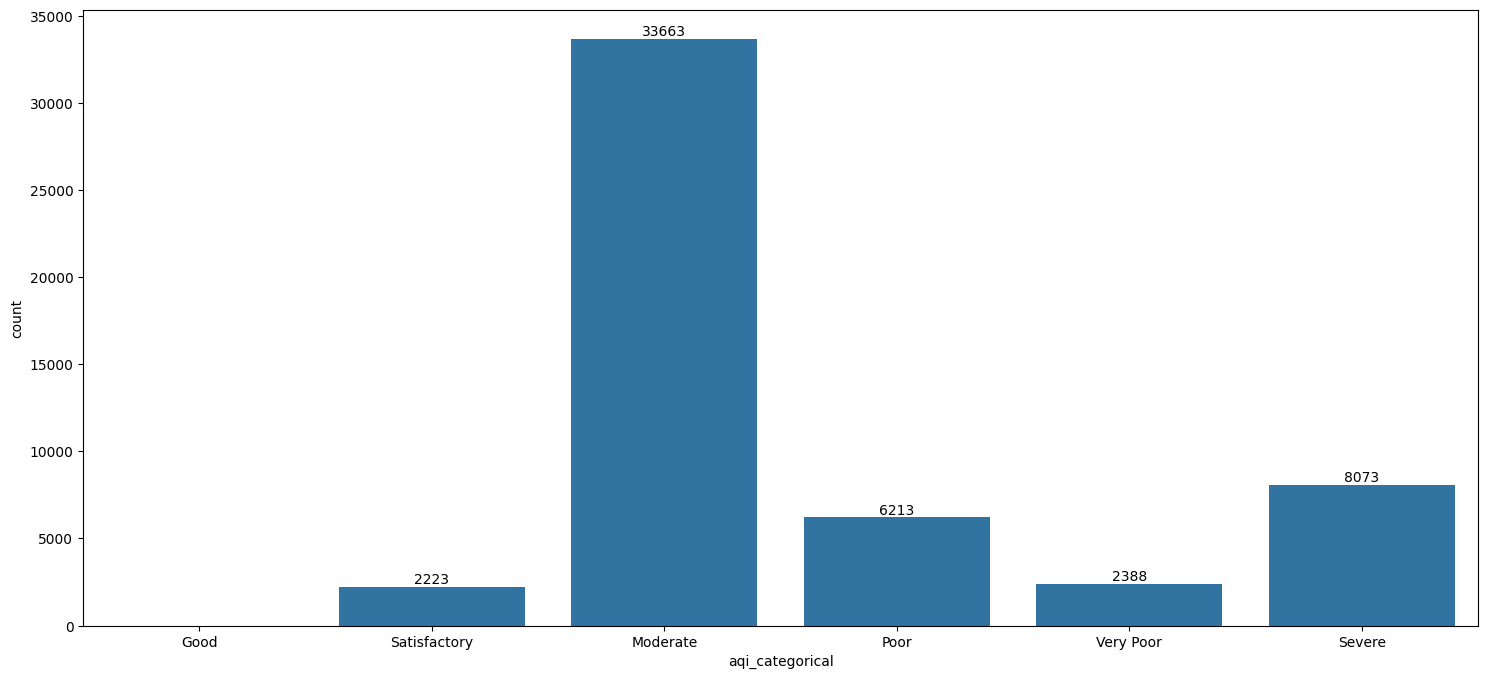

In [ ]:
plt.figure(figsize=(18,8))

a=sns.countplot(x=df['aqi_categorical'],order=order)
for bars in a.containers:
  plt.bar_label(bars)

### Key Insights from AQI Category Distribution

* The majority of AQI records fall under the **Moderate** category (~33,663), showing that pollution levels are frequently above safe limits.
* **Severe AQI conditions** were also observed frequently (~8,073), indicating recurring extreme pollution events.
* **Poor AQI levels** occurred a significant number of times (~6,213), reflecting unhealthy air conditions.
* **Very Poor** air quality was recorded around **2,388** times.
* **Satisfactory AQI** was comparatively low (~2,223), showing limited periods of cleaner air.
* The **Good AQI category was almost absent**, indicating that truly clean air conditions are very rare in the dataset.

### Short Conclusion

* Delhi experienced predominantly **Moderate to Severe air quality conditions**.
* Clean air conditions were extremely limited, highlighting persistent urban air pollution problems.


**Q . what is the percentage of contribution by the aqi categorical?**

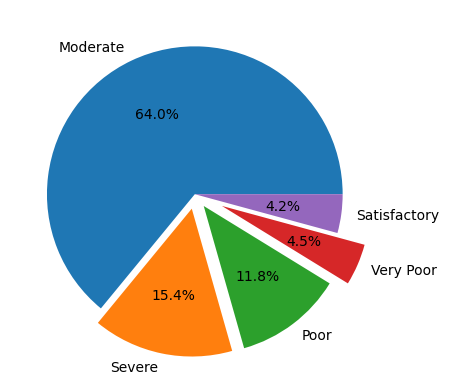

In [ ]:
aqi_pie=df['aqi_categorical'].value_counts()

plt.pie(
    x=aqi_pie.values,
    labels=aqi_pie.index,
    autopct='%1.1f%%',
    # shadow=True,
    explode=[0,0.1,0.1,0.2,0]

)

plt.show()

### Key Insights from AQI Percentage Distribution

* **64%** of the AQI records fall under the **Moderate** category, making it the most dominant air quality condition.
* Around **15.4%** of the observations belong to the **Severe** category, indicating frequent extreme pollution conditions.
* **11.8%** of the AQI levels fall under the **Poor** category.
* **Very Poor** air quality contributes about **4.5%** of the total observations.
* Only **4.2%** of the records are classified as **Satisfactory**.
* The **Good AQI category is nearly absent**, showing that clean air conditions are extremely rare.

### Short Conclusion

* Most of Delhi’s air quality conditions remain in the **Moderate to Severe range**.
* The percentage distribution clearly indicates persistent pollution issues with very limited periods of clean air.


# **Weather Infulence**

**Q . Behaviour of temparature in different location through out the year**

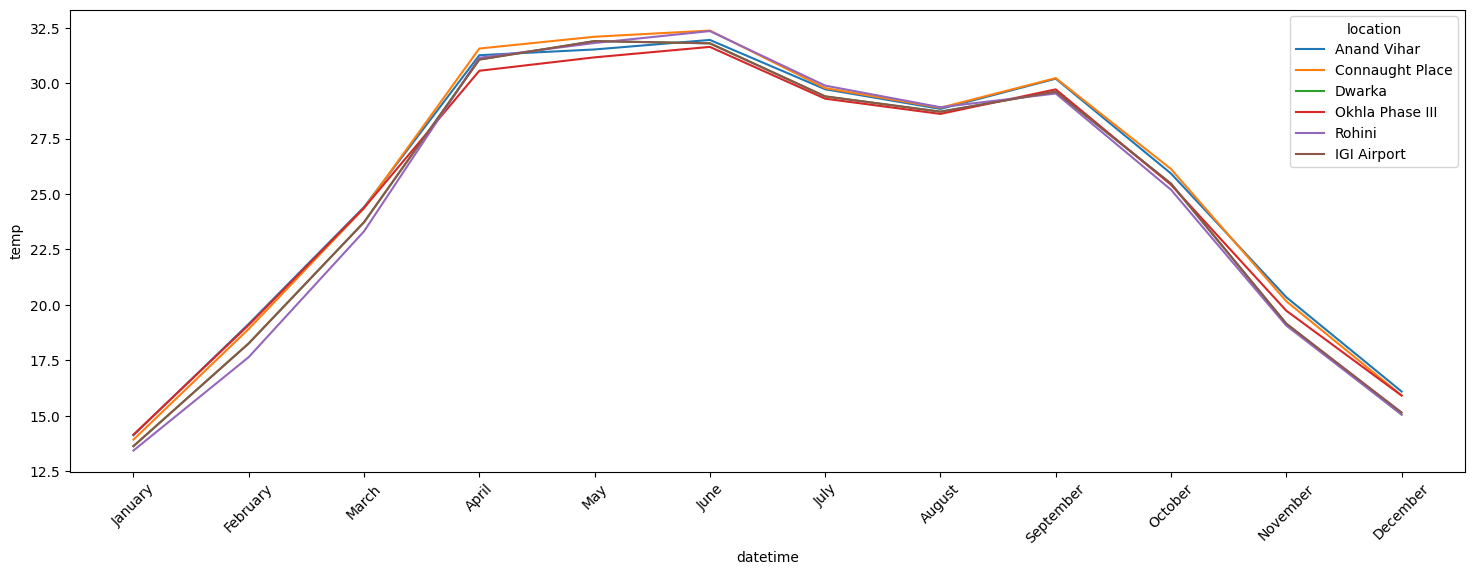

In [ ]:
plt.figure(figsize=(18,6))
ax=sns.lineplot(y=df['temp'],x=df['datetime'].dt.month_name(),hue=df['location'],errorbar=None)
plt.xticks(rotation=45)
plt.show()

### Key Insights from Monthly Temperature Trend

* Temperature gradually **increases from January to June** across all locations.
* **May and June** recorded the **highest temperatures** (~32°C).
* After June, temperature starts **decreasing slowly** toward winter.
* **December and January** had the **lowest temperatures** (~14–16°C).
* All locations show **very similar temperature patterns**, indicating uniform seasonal climate across Delhi.
* **September** shows a slight rise again before temperatures drop sharply from October onward.
* Seasonal transition is clearly visible:

  * **Summer:** April–June
  * **Monsoon:** July–September
  * **Winter:** November–January

### Short Conclusion

* Delhi experiences **extreme seasonal variation** with very hot summers and cool winters.
* Temperature patterns remain **consistent across all monitored locations**.
* Peak summer months may contribute to increased dust and particulate pollution levels.


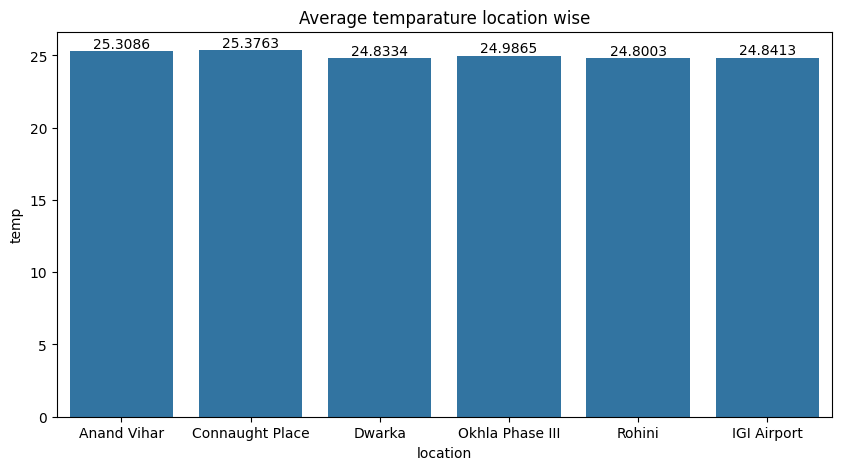

In [ ]:
plt.figure(figsize=(10,5))
a=sns.barplot(x=df['location'],y=df['temp'],errorbar=None)
plt.title("Average temparature location wise")
for bar in a.containers:
  plt.bar_label(bar)

**Q . How do weather conditions (temperature, humidity, wind,pressure ) influence AQI levels?**

<Axes: >

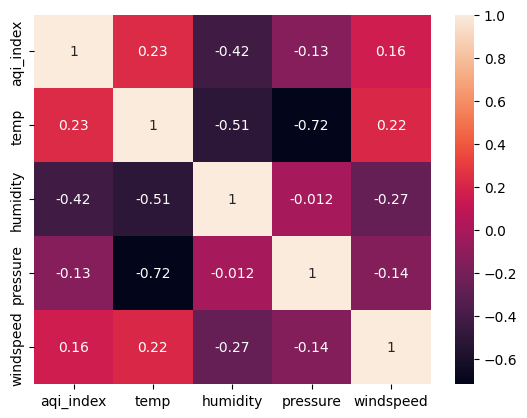

In [ ]:
cor=df[['aqi_index','temp','humidity','pressure','windspeed']].corr()
sns.heatmap(cor,annot=True)

### Key Insights from AQI vs Weather Factors Correlation

* **AQI and humidity** have a **moderate negative correlation (-0.42)**
  → Higher humidity generally helps reduce pollution levels.

* **AQI and temperature** show a **weak positive correlation (0.23)**
  → Pollution slightly increases during hotter conditions.

* **AQI and wind speed** have a **small positive relation (0.16)**
  → Wind has limited direct impact on AQI in this dataset.

* **Temperature and pressure** have a **strong negative correlation (-0.72)**
  → As temperature rises, atmospheric pressure decreases.

* **Temperature and humidity** also show a **moderate negative relationship (-0.51)**
  → Hotter days are usually drier.

* **Humidity and wind speed** have a weak negative correlation (-0.27)**
  → Higher winds slightly reduce moisture concentration.

* **Pressure has very weak relation with AQI (-0.13)**
  → Atmospheric pressure has minimal direct effect on pollution levels.

### Short Conclusion

* **Humidity plays an important role in reducing AQI levels.**
* **Hot and dry conditions slightly increase pollution concentration.**
* Weather conditions influence air quality, but particulate pollutants remain the major contributors to AQI changes.


**Q . Does higher wind speed help in reducing or incereasing pollution levels?**

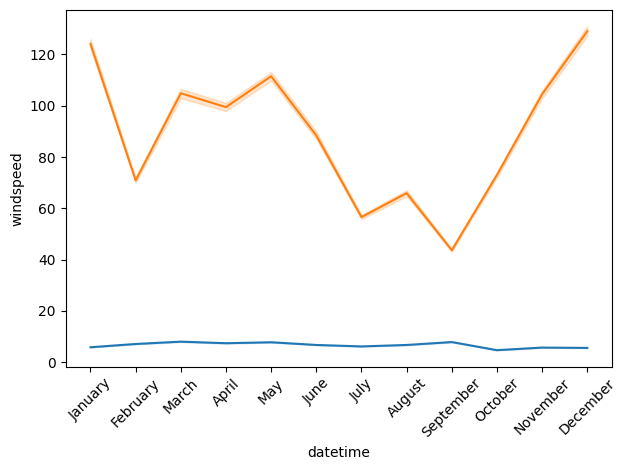

In [ ]:

sns.lineplot(x=df['datetime'].dt.month_name(),y=df['windspeed'])
sns.lineplot(x=df['datetime'].dt.month_name(),y=df['pm2_5'])
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Columns you want to scale
cols = ['windspeed', 'pm2_5', 'pm10', 'co', 'no2']

# Create scaler
scaler = MinMaxScaler()

# Update scaled dataframe
scaled_df = pd.DataFrame(
    scaler.fit_transform(df[cols]),
    columns=cols
)

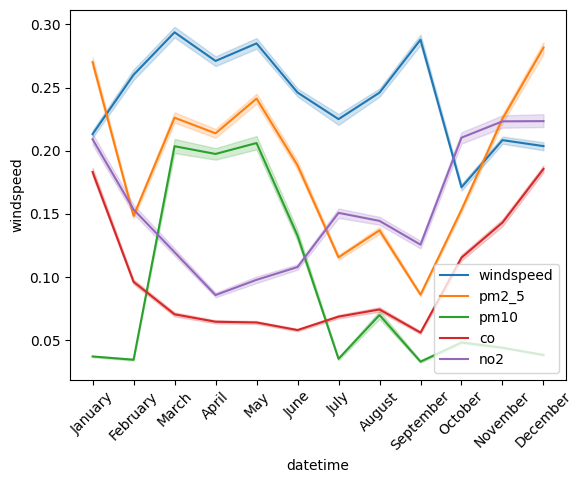

In [ ]:
sns.lineplot(x=df['datetime'].dt.month_name(),y=scaled_df['windspeed'],label="windspeed")
sns.lineplot(x=df['datetime'].dt.month_name(),y=scaled_df['pm2_5'],label="pm2_5")
sns.lineplot(x=df['datetime'].dt.month_name(),y=scaled_df['pm10'],label="pm10")
sns.lineplot(x=df['datetime'].dt.month_name(),y=scaled_df['co'],label="co")
sns.lineplot(x=df['datetime'].dt.month_name(),y=scaled_df['no2'],label="no2")

plt.xticks(rotation=45)

plt.show()

<Axes: >

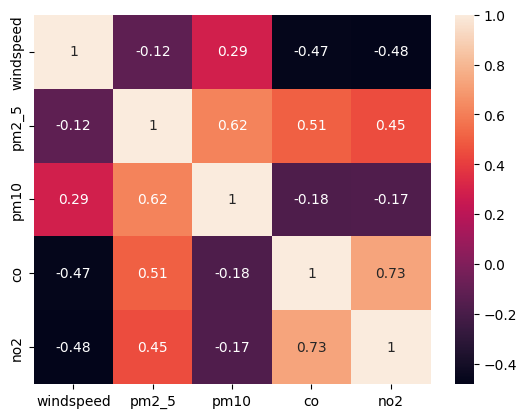

In [ ]:
cor = df[['windspeed', 'pm2_5', 'pm10', 'co', 'no2']].corr()
sns.heatmap(cor,annot=True)

### Key Insights from Weather vs Pollutants Correlation

* **Wind speed has a negative correlation with CO (-0.47) and NO2 (-0.48)**
  → Higher wind helps disperse harmful gases and improves air quality.

* **Wind speed has very weak relation with PM2.5 (-0.12)**
  → Wind alone is less effective in reducing fine particulate matter.

* **PM2.5 and PM10** show a **strong positive correlation (0.62)**
  → Dust and particulate pollutants increase together.

* **CO and NO2** have a **very strong positive correlation (0.73)**
  → Both mainly originate from traffic emissions and fuel burning.

* **PM2.5 is moderately related with CO (0.51) and NO2 (0.45)**
  → Vehicular pollution contributes to fine particles as well.

* **PM10 has weak negative relation with CO and NO2**
  → Dust pollution behaves differently from gaseous pollutants.

### Short Conclusion

* **Higher wind speeds help reduce gaseous pollutants significantly.**
* **Traffic and fuel combustion are major sources of CO and NO2.**
* **Particulate matter pollution (PM2.5 & PM10) remains a key air quality concern.**


**Q.Are there weather patterns in pollution levels?**

In [ ]:
order=weather_order = [
    'Fog',
    'Clear sky',
    'Mainly clear',
    'Partly cloudy',
    'Overcast',
    'Drizzle: Light',
    'Drizzle: Moderate',
    'Drizzle: Dense',
    'Rain: Slight',
    'Rain: Moderate',
    'Rain: Heavy',

]

df['weather'] = pd.Categorical(
    df['weather'],
    categories=order,
    ordered=True
)

In [ ]:
df['weather'].value_counts()

,count
weather,
Clear sky,30086
Overcast,10285
Mainly clear,4444
Drizzle: Light,3090
Partly cloudy,2557
Drizzle: Moderate,643
Rain: Moderate,421
Rain: Slight,416
Fog,334


In [ ]:
df.groupby('weather').nunique()

/tmp/ipykernel_5676/989703782.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('weather').nunique()


,datetime,location,lat,lon,temp,humidity,pressure,windspeed,aqi_index,pm2_5,pm10,co,no2,aqi_categorical
weather,,,,,,,,,,,,,,
Fog,67,6,6,6,52,10,95,53,56,104,108,309,126,2
Clear sky,5661,6,6,6,375,96,315,210,421,992,1649,2802,1297,5
Mainly clear,1784,6,6,6,357,95,298,190,333,814,1176,1517,805,5
Partly cloudy,1222,6,6,6,319,96,287,166,288,705,938,1226,698,5
Overcast,2412,6,6,6,345,96,308,191,365,942,1398,2256,1017,5
Drizzle: Light,1101,6,6,6,245,75,275,188,243,639,844,855,548,5
Drizzle: Moderate,363,6,6,6,145,63,182,163,148,329,365,413,302,5
Drizzle: Dense,148,6,6,6,83,39,118,108,96,152,153,191,136,5
Rain: Slight,236,6,6,6,109,49,153,134,135,225,257,308,222,5


**Q . Are there weather patterns in pollution levels?**

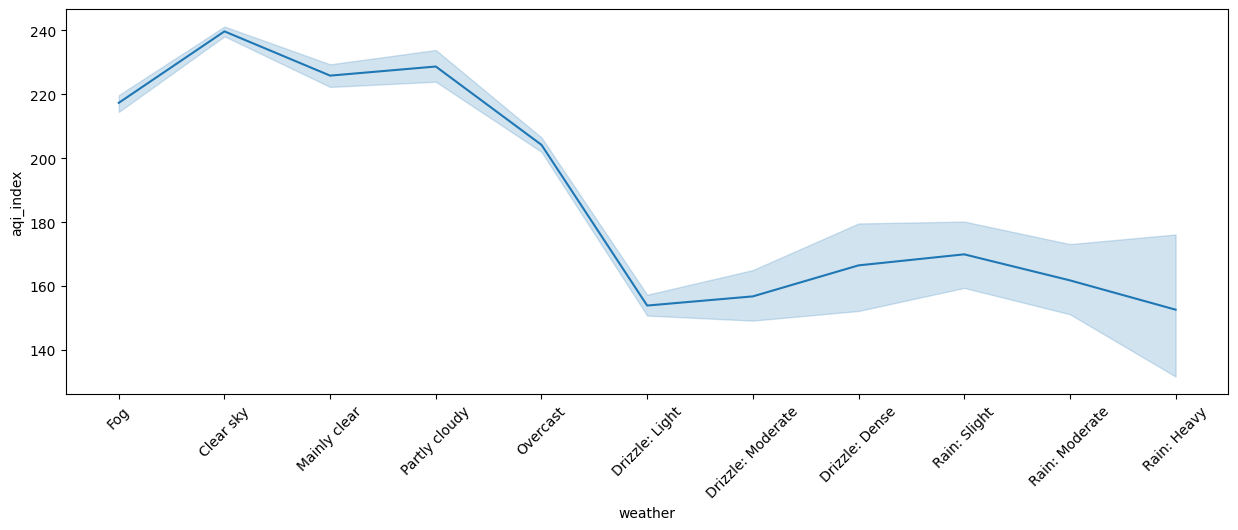

In [ ]:
plt.figure(figsize=(15,5))

sns.lineplot(y=df['aqi_index'],x=df['weather'])
plt.xticks(rotation=45)

plt.show()

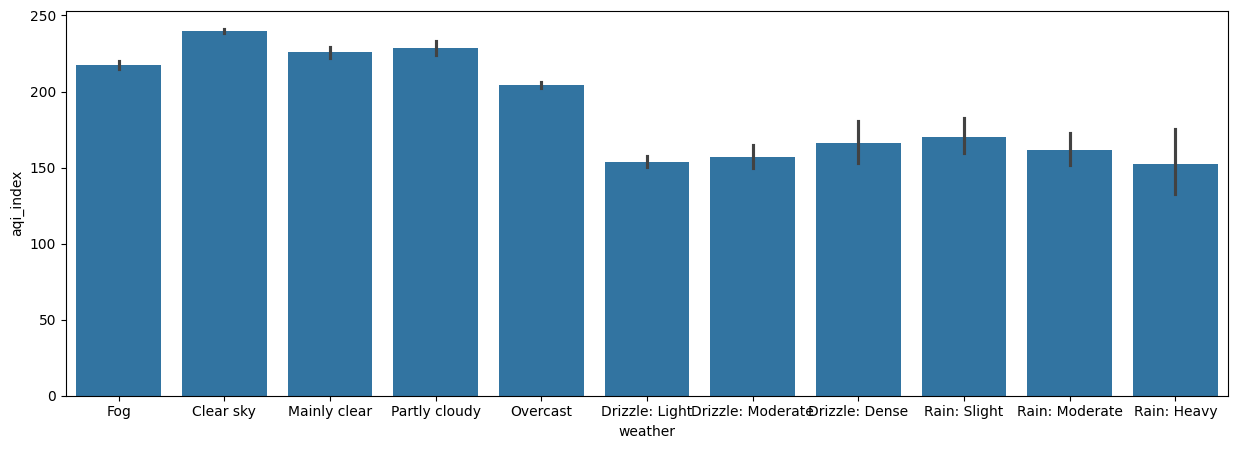

In [ ]:

plt.figure(figsize=(15,5))

sns.barplot(y=df['aqi_index'],x=df['weather'],order=order)

plt.show()

### Key Insights from Weather vs AQI Graph

* **Clear sky conditions** recorded the **highest AQI levels** (~240).
* **Partly cloudy and mainly clear weather** also showed high pollution levels.
* **Rainy and drizzling conditions** had the **lowest AQI values**.
* **Heavy rain** significantly reduced air pollution due to pollutant washout.
* **Fog conditions** still showed high AQI because pollutants get trapped near the surface.
* **Overcast weather** had slightly lower AQI compared to clear sky conditions.
* AQI generally decreases when **moisture and rainfall increase**.

### Short Conclusion

* **Rainfall helps improve air quality by removing pollutants from the atmosphere.**
* **Clear and dry weather conditions increase pollution accumulation.**
* **Foggy weather can worsen pollution by trapping pollutants close to the ground.**


In [ ]:
df.head(1)

,datetime,location,lat,lon,temp,humidity,pressure,windspeed,weather,aqi_index,pm2_5,pm10,co,no2,aqi_categorical
0,2025-01-01,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,197,185.8,188.6,1907,56.7,Moderate


# **Time Based**

**8.Which period of time the pollution will increase in a day?**

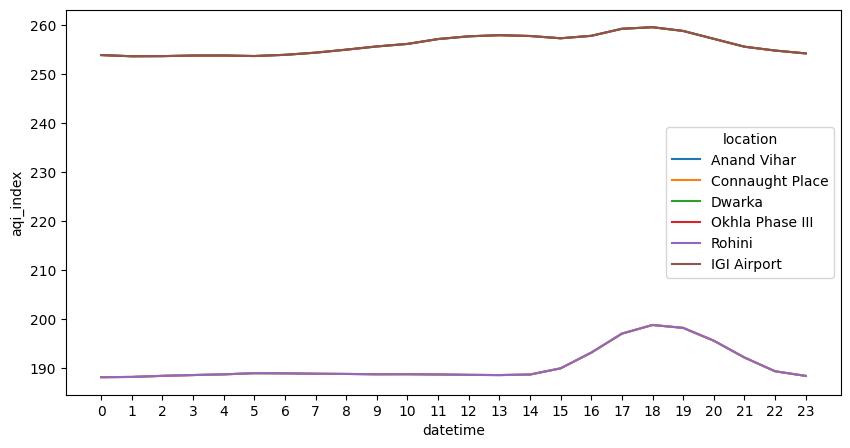

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=df['datetime'].dt.hour,y=df['aqi_index'],hue=df['location'],errorbar=None)
plt.xticks(range(24))
plt.show()

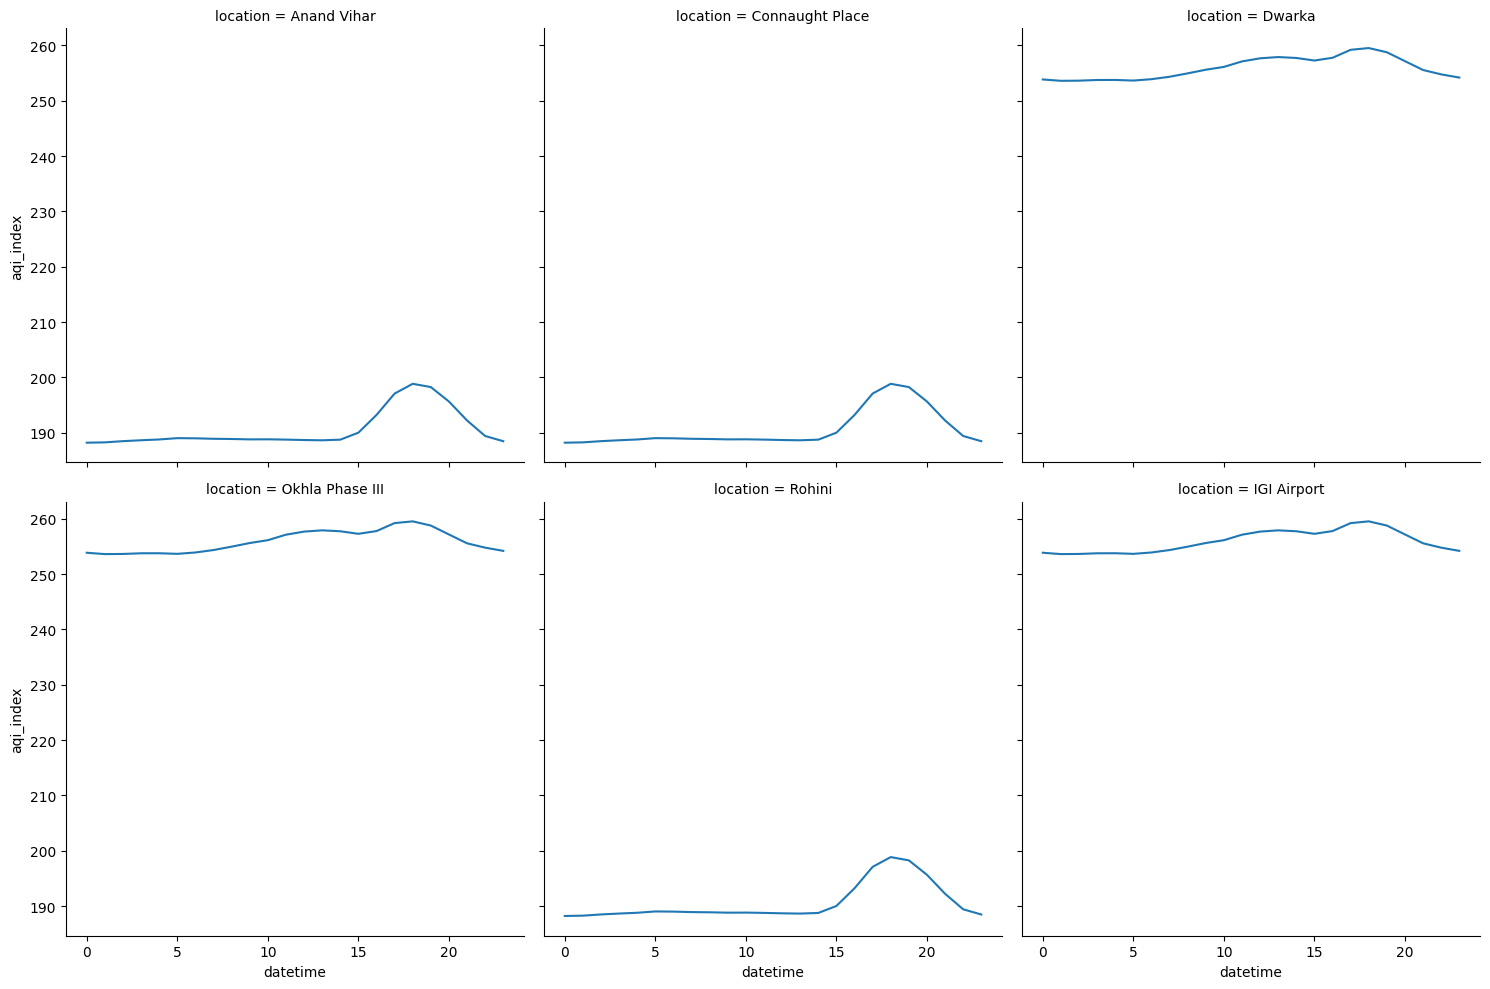

In [ ]:

sns.relplot(x=df['datetime'].dt.hour,y=df['aqi_index'],col=df['location'],col_wrap=3,errorbar=None,kind='line')

plt.show()

### Key Insights from Hourly AQI Trend

* AQI remains **consistently high throughout the day** across all locations.
* **IGI Airport** recorded the **highest AQI levels** overall (~254–260).
* **Rohini** showed comparatively lower AQI than other locations.
* Pollution levels gradually **increase during evening hours (5 PM – 8 PM)**.
* The **peak AQI** is observed around **6 PM to 7 PM**, likely due to traffic and human activity.
* After 8 PM, AQI starts **slightly decreasing**.
* Morning and late-night hours show relatively stable pollution levels.
* Most locations follow a **similar hourly trend**, indicating city-wide pollution influence.

### Short Conclusion

* **Evening hours experience the worst air quality.**
* **Traffic and urban activities strongly affect AQI during peak hours.**
* Delhi maintains consistently high pollution levels throughout the day.


**Q . How does AQI vary across weekdays vs weekends?**

In [ ]:

df['datetime'].dt.day_name().unique()

array(['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday'], dtype=object)

In [ ]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

df['day'] = pd.Categorical(
    df['datetime'].dt.day_name(),
    categories=day_order,
    ordered=True
)


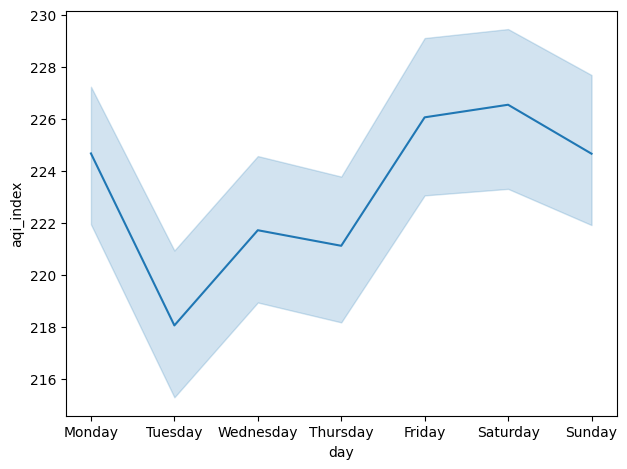

In [ ]:
g=sns.lineplot(x=df['day'],y=df['aqi_index'])


plt.tight_layout()
plt.show()

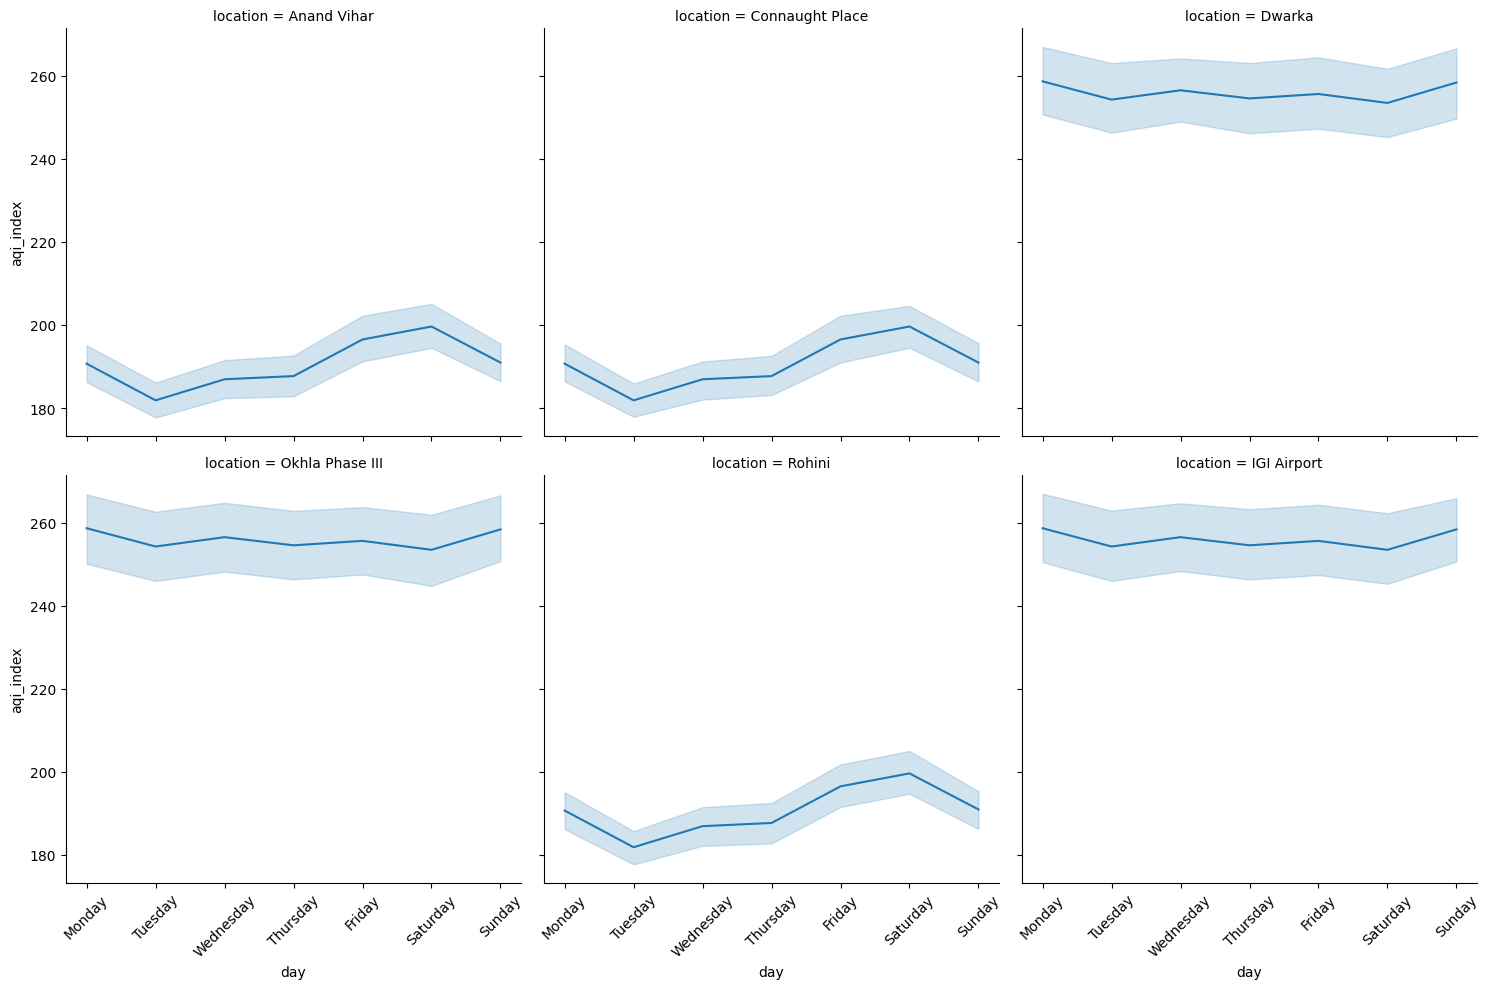

In [ ]:
g=sns.relplot(x=df['day'],y=df['aqi_index'],col=df['location'],kind='line',col_wrap=3)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Key Insights from Weekly AQI Trend

* **Saturday** recorded the **highest AQI levels** during the week.
* **Tuesday** had the **lowest AQI**, indicating comparatively cleaner air.
* AQI gradually **increases from Thursday to Saturday**.
* **Weekend pollution levels** are slightly higher than weekdays.
* The AQI variation across the week is **moderate and stable**, without extreme fluctuations.
* **Friday and Saturday** consistently show elevated pollution levels, possibly due to increased traffic and human activities.

### Short Conclusion

* **Air quality worsens toward the weekend.**
* **Mid-week days experience comparatively better air quality.**
* Pollution remains consistently high throughout the week, showing persistent urban pollution impact.


# **Location-Based Analysis**

In [ ]:
df.head(1)

,datetime,location,lat,lon,temp,humidity,pressure,windspeed,weather,aqi_index,pm2_5,pm10,co,no2,aqi_categorical,day,Zones
0,2025-01-01,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,197,185.8,188.6,1907,56.7,Moderate,Wednesday,Residential


**ResidentialZone**

  Dwarka : Planned residential sub-city

  Rohini : Large residential zone

  Anand Vihar : Primarily residential
  
**CommercialZone**

  Connaught Place : Central business district (offices, retail, heavy traffic)

  IGI Airport : High commercial activity (airport operations, transport hub)

**IndustrialZone**

  Okhla Phase III : Major industrial hub (factories, manufacturin

In [ ]:
def zones(loc):
  res=['Dwarka','Rohini','Anand Vihar']
  ind=['Okhla Phase III']
  com=['Connaught Place','IGI Airport']
  if loc in res:
    return "Residential"
  elif loc in ind:
    return "Industry"
  else:
    return "commercial"



In [ ]:
df['Zones']=df['location'].apply(zones)

**12.Which zones  in Delhi experience the highest pollution levels?**

<Axes: xlabel='Zones', ylabel='aqi_index'>

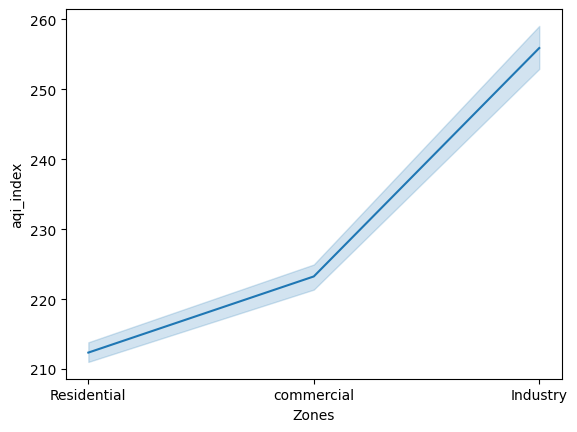

In [ ]:
sns.lineplot(x=df['Zones'],y=df['aqi_index'])

In [ ]:
df.head(1)

,datetime,location,lat,lon,temp,humidity,pressure,windspeed,weather,aqi_index,pm2_5,pm10,co,no2,aqi_categorical,day,Zones
0,2025-01-01,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,197,185.8,188.6,1907,56.7,Moderate,Wednesday,Residential


In [ ]:
df.groupby('Zones')[['pm2_5', 'pm10', 'co', 'no2']].mean().reset_index()


,Zones,pm2_5,pm10,co,no2
0,Industry,98.770080,401.752306,898.261187,37.023505
1,Residential,86.466549,266.699498,853.352435,34.915841
2,commercial,89.542432,300.462700,862.373573,35.442757


**Q . How does pollution vary across different zones (residential, industrial, commercial)?**

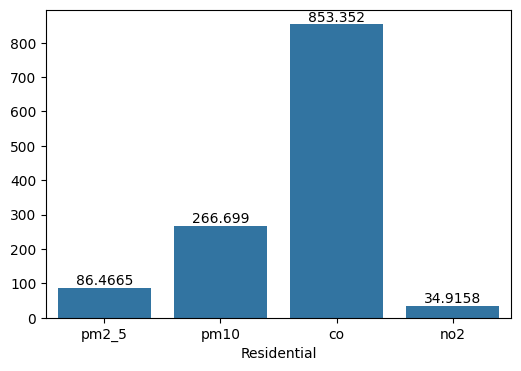

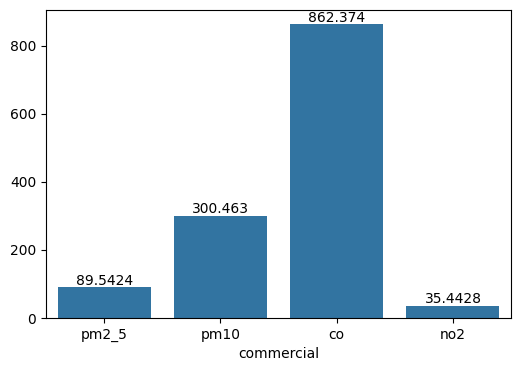

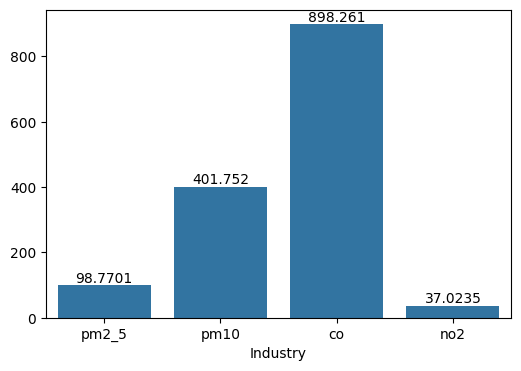

In [ ]:
# 13.

z=df['Zones'].unique().tolist()
for i in z:
  plt.figure(figsize=(6,4))
  x=df.groupby('Zones')[['pm2_5', 'pm10', 'co', 'no2']].get_group(i).mean()
  ax=sns.barplot(x=x.index,y=x.values)

  for bars in ax.containers:
    plt.bar_label(bars)
  plt.xlabel(i)
  plt.show()

### Key Insights from Area-wise Pollutant Comparison

* **Industrial areas** recorded the **highest pollution levels** among all area types.
* **CO (Carbon Monoxide)** is the dominant pollutant across residential, commercial, and industrial areas.
* **PM10 levels** are significantly higher in industrial areas, indicating strong dust and industrial emission impact.
* **Commercial areas** show slightly higher pollution levels than residential areas due to traffic and business activities.
* **Residential areas** recorded the lowest overall pollutant concentrations compared to commercial and industrial zones.
* **NO2 levels** remain comparatively lower than other pollutants in all area categories.
* Pollution levels consistently increase from:

  * **Residential → Commercial → Industrial areas**

### Short Conclusion

* Industrial activities and urban traffic are major contributors to pollution levels.
* Industrial zones experience the highest pollutant concentration, especially for CO and PM10.
* Residential areas are comparatively less polluted but still affected by urban emissions.


**Q .Which locations are most sensitive to weather changes?**

<Axes: xlabel='location', ylabel='count'>

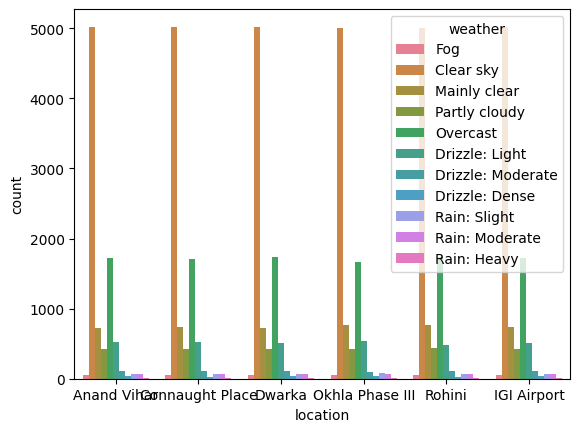

In [ ]:
sns.countplot(x=df['location'],hue=df['weather'])

### Key Insights from Weather Distribution Across Locations

* **Clear sky weather** is the **most frequently observed condition** across all locations.
* **Overcast weather** is the second most common weather condition.
* **Rainy conditions** (light, moderate, heavy) occur much less frequently compared to dry weather.
* **Fog occurrences are very low**, but still important because they increase pollution trapping.
* All locations show **almost similar weather distribution patterns**, indicating consistent regional climate conditions.
* **Dwarka and IGI Airport** show slightly higher counts for cloudy and overcast conditions.
* **Drizzle and dense drizzle** events are comparatively rare throughout the dataset.

### Short Conclusion

* Delhi experiences **mostly dry and clear weather conditions**, which supports pollution accumulation.
* **Rainfall events are limited**, reducing natural pollutant cleansing opportunities.
* Similar weather patterns across locations indicate that pollution differences are mainly influenced by traffic, industrial activity, and local emissions.


corelation and relationship

<Axes: >

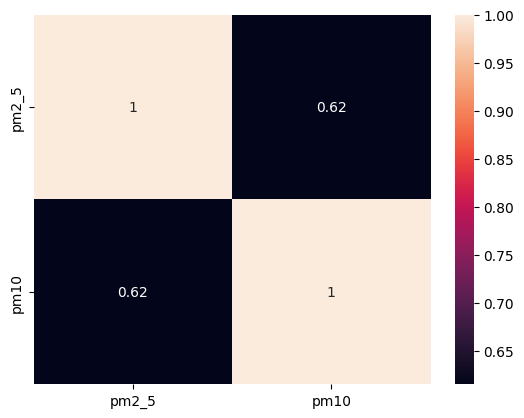

In [ ]:
# 15.Is there a strong relationship between PM2.5 and PM10 levels?
cor=df[['pm2_5','pm10']].corr()

sns.heatmap(cor,annot=True)

### Key Insights from Pollutants Correlation Heatmap

* **PM2.5 and PM10** have a **strong positive correlation (0.62)**
  → Both particulate pollutants increase together.

* **NO2 and CO** show the **strongest correlation (0.73)**
  → They mainly come from common sources like vehicle emissions and fuel combustion.

* **PM2.5 has moderate positive correlation with CO (0.51) and NO2 (0.45)**
  → Vehicular and combustion activities also contribute to fine particulate pollution.

* **PM10 has weak negative correlation with NO2 (-0.17) and CO (-0.18)**
  → Dust pollution behaves differently compared to gaseous pollutants.

* Pollutants do not increase equally; particulate matter and gaseous pollutants follow different patterns.

### Short Conclusion

* **Vehicle emissions strongly influence NO2 and CO levels.**
* **PM2.5 and PM10 are closely related and major pollution contributors.**
* Controlling traffic emissions and dust pollution can significantly improve air quality.


**Q .Is there a correlation between pollutants like PM2.5, PM10, NO2, and CO?**

<Axes: >

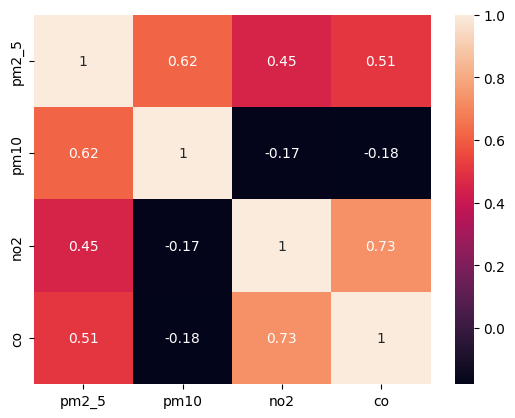

In [ ]:
x=df[['pm2_5','pm10','no2','co']].corr()
sns.heatmap(x,annot=True)

In [ ]:
df.to_csv("DelhiWeatherAqi_cleaned.csv",index=False)

# Overall Conclusion (Accurate Data-Based Insights)

* The analysis shows that **AQI levels vary strongly with seasonal and weather changes** across all Delhi locations.
* **March, April, and May** recorded the **highest AQI values**, indicating severe pollution during pre-summer and summer months.
* **July and September** showed the **lowest AQI levels**, suggesting that monsoon conditions help reduce pollution concentration.
* **Dwarka, Okhla Phase III, and IGI Airport** consistently showed higher AQI and PM10 levels compared to other locations.
* **PM10 had the strongest positive correlation with AQI (0.74)**, making it the most influential pollutant in overall air quality deterioration.
* **PM2.5 also showed a moderate positive relationship with AQI (0.50)**, contributing significantly to pollution levels.
* **NO2 and CO were strongly correlated (0.73)**, indicating that both pollutants likely originate from similar emission sources.
* Weather conditions significantly affected AQI:

  * **Clear sky and fog conditions** showed higher AQI values.
  * **Rain and drizzle conditions** showed noticeably lower AQI values.
* **Heavy rain and drizzle-light weather** were associated with the cleanest air conditions in the dataset.
* **Humidity showed a negative correlation with AQI (-0.42)**, meaning increased moisture levels were associated with lower pollution.
* **Temperature had only a weak positive relationship with AQI (0.23)**, indicating limited direct influence.
* Hourly trends showed AQI remaining relatively stable throughout the day, with a **slight increase during evening hours**.
* Weekly analysis showed only **small AQI variations across days**, indicating pollution persists consistently throughout the week.
* All monitored locations followed a **similar annual pollution pattern**, showing that seasonal weather changes strongly influence Delhi’s air quality.


## Recommendations to the Government

* Implement stricter controls on **construction and road dust**, especially in high-pollution areas like Dwarka, Okhla Phase III, and IGI Airport.
* Increase the use of **mechanized road cleaning and regular water sprinkling** during dry summer months.
* Strengthen **vehicle emission regulations** and conduct frequent emission testing for public and private transport.
* Expand and improve **public transportation systems** to reduce traffic congestion and vehicular pollution.
* Promote faster adoption of **electric vehicles (EVs)** through subsidies and charging infrastructure.
* Enforce stricter monitoring of **industrial emissions** and ensure industries follow pollution control standards.
* Develop a **seasonal pollution action plan** for March–May when AQI levels become severe.
* Increase urban green cover through **large-scale tree plantation and green belts** near roads and industrial zones.
* Introduce **real-time AQI alert systems** and public awareness campaigns during high pollution periods.
* Restrict heavy vehicle movement during **peak pollution hours and highly polluted days**.
* Improve coordination between environmental, transport, and municipal departments for integrated pollution management.
* Encourage use of **clean fuels and renewable energy sources** to reduce combustion-related pollutants.
* Strengthen monitoring stations and expand air quality data collection across more locations in Delhi.
* Implement emergency pollution control measures during **clear sky and foggy conditions**, when pollutant accumulation is highest.
* Promote sustainable urban planning to reduce long-term pollution concentration in densely populated areas.


## Public Cautions / Alerts for People

* Avoid outdoor activities during **high AQI periods**, especially in March–May and during evening hours.
* Children, elderly people, and individuals with respiratory problems should **limit outdoor exposure** on polluted days.
* Use **masks (N95/N99)** while traveling in highly polluted areas.
* Reduce outdoor exercise and jogging when AQI reaches unhealthy levels.
* Keep windows closed during severe pollution and fog conditions to reduce indoor pollutant exposure.
* Use **air purifiers** indoors where pollution levels are high.
* Stay hydrated and maintain healthy indoor ventilation when air quality improves.
* Avoid burning waste, firecrackers, or biomass, which can increase local pollution.
* Prefer **public transport or carpooling** to help reduce vehicular emissions.
* Follow official AQI alerts and weather advisories before planning outdoor activities.
* People with asthma or breathing issues should keep prescribed medications readily available.
* Schools may reduce outdoor activities for students during severe pollution days.
* Citizens should report illegal waste burning or excessive dust pollution to local authorities.
* During foggy and clear-sky pollution conditions, minimize prolonged exposure outdoors.
* Encourage community participation in tree plantation and local environmental protection activities.


# Final statement

This analysis highlights the significant impact of particulate pollutants, weather conditions, and urban activities on Delhi’s air quality. The findings emphasize the need for continuous monitoring, effective pollution management, and increased public awareness to achieve a healthier and more sustainable environment for the future.